In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [28]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

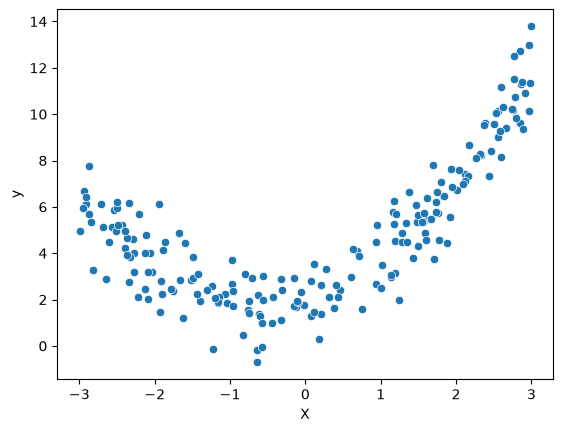

In [29]:
sns.scatterplot(x=X.ravel(), y=y.ravel())
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [34]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.97]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[4.78]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[23.57]


In [35]:
r2_score(y_test, lr.predict(X_test))

0.306966205425097

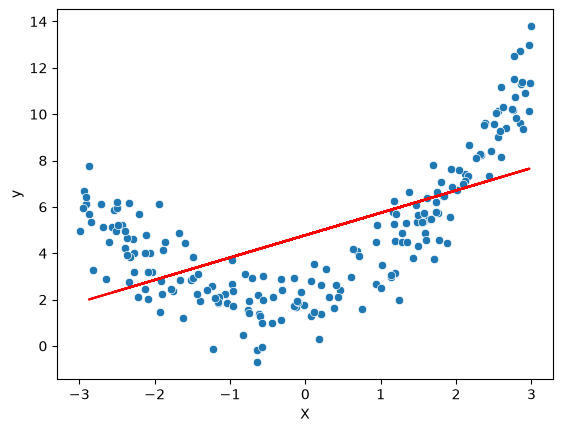

In [40]:
sns.scatterplot(x=X.ravel(), y=y.ravel())
plt.plot(X_test, lr.predict(X_test), color='red')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

# Simple Polynomial Linear Regression

In [84]:
pf = PolynomialFeatures(degree=2)

In [86]:
X_train.shape

(160, 1)

In [85]:
pf.fit_transform(X_train).shape

(160, 3)

In [87]:
X_train_t = pf.fit_transform(X_train)
X_test_t = pf.fit_transform(X_test)

In [88]:
lr.fit(X_train_t, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 3)","[[0. ,0.94,0.79]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[2.04]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[35. ,23.56, 0. ]"


In [89]:
lr.coef_

array([[0.        , 0.94006418, 0.7882578 ]])

In [90]:
lr.intercept_

array([2.04012815])

In [91]:
r2_score(y_test, lr.predict(X_test_t))

0.8605572083840344

In [92]:
# Dont know what is this
X_smooth = np.linspace(-3, 3, 200).reshape(-1, 1)
X_smooth_poly = pf.transform(X_smooth)
y_smooth_pred = lr.predict(X_smooth_poly)

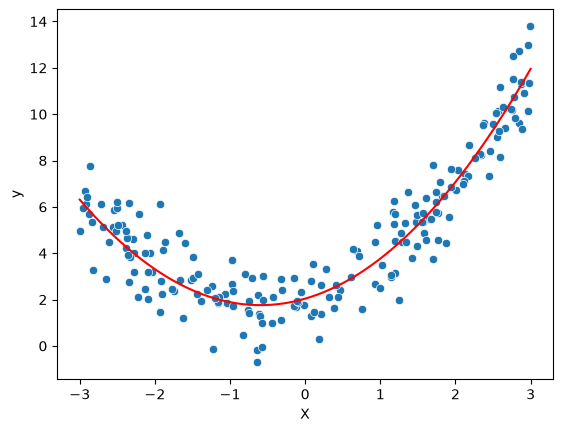

In [93]:
sns.scatterplot(x=X.ravel(), y=y.ravel())
plt.plot(X_smooth, y_smooth_pred, color='red')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

# In 3D regression

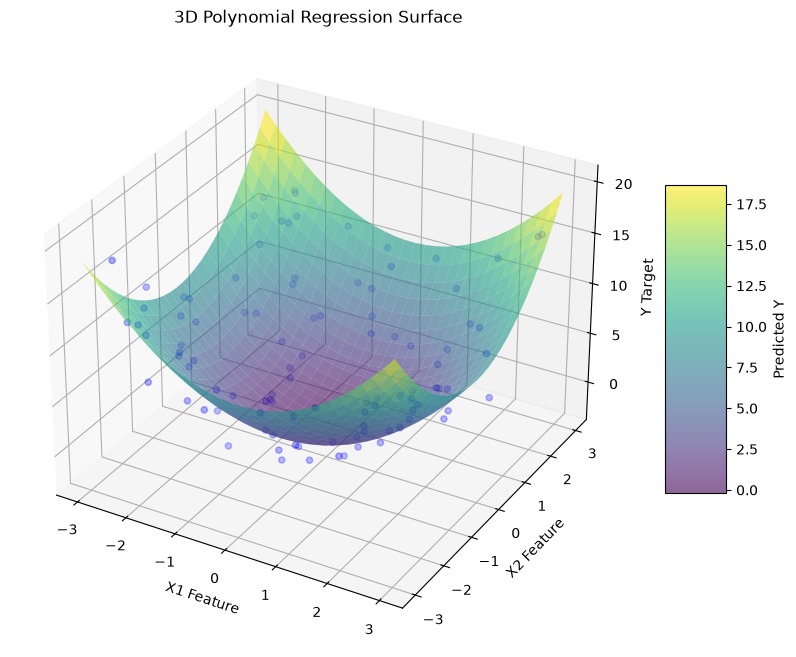

In [123]:
# Google

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Generate sample 3D non-linear data
np.random.seed(42)
X1 = np.random.rand(100) * 6 - 3  # Feature 1
X2 = np.random.rand(100) * 6 - 3  # Feature 2
# Non-linear relationship: Y = X1^2 + X2^2 + noise
Y = X1**2 + X2**2 + np.random.randn(100) * 2  

# Combine X1 and X2 into a single feature matrix
X = np.column_stack((X1, X2))

# 2. Transform features to polynomial (Degree 2 - Quadratic Surface)
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# 3. Fit the Linear Regression model
model = LinearRegression()
model.fit(X_poly, Y)

# 4. Generate dense grid for a smooth 3D surface plot
x1_range = np.linspace(-3, 3, 30)
x2_range = np.linspace(-3, 3, 30)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)

# Flatten grid to feed into the model prediction
X_grid_flat = np.column_stack((X1_grid.ravel(), X2_grid.ravel()))
X_grid_poly = poly_features.transform(X_grid_flat)
Y_grid_pred = model.predict(X_grid_poly)

# Reshape predictions back to the 2D grid shape
Y_grid_pred = Y_grid_pred.reshape(X1_grid.shape)

# 5. Plot the 3D Scatter and Surface
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot raw data points
ax.scatter(X1, X2, Y, color='blue', alpha=0.6, label='Data Points')

# Plot the regression surface
surface = ax.plot_surface(X1_grid, X2_grid, Y_grid_pred, cmap='viridis', alpha=0.6, edgecolor='none')

# Labels and styling
ax.set_xlabel('X1 Feature')
ax.set_ylabel('X2 Feature')
ax.set_zlabel('Y Target')
ax.set_title('3D Polynomial Regression Surface')
fig.colorbar(surface, ax=ax, shrink=0.5, aspect=5, label='Predicted Y')

plt.show()


In [161]:
# 1. Generate sample 3D non-linear data
np.random.seed(42)
X1 = np.random.rand(100) * 6 - 3  # Feature 1
X2 = np.random.rand(100) * 6 - 3  # Feature 2
# Non-linear relationship: Y = X1^2 + X2^2 + noise
Y = X1**2 + X2**2 + 2 + np.random.randn(100) * 2  

In [162]:
X = np.column_stack([X1, X2])

In [163]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, random_state=42, test_size=0.2)

In [164]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [165]:
pf = PolynomialFeatures(degree=2, include_bias=True)

In [166]:
X_train_t_3d = pf.fit_transform(X_train)
X_test_t_3d = pf.fit_transform(X_test)

In [167]:
lr_3d = LinearRegression()

In [168]:
lr_3d.fit(X_train_t_3d, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0. ,-0.09, 0.26, 0.93, 0.02, 1.12]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.972
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[27.07,24.35,21.89,15.75,14.97, 0. ]"


In [169]:
lr_3d.intercept_

np.float64(1.9720178715948844)

In [170]:
lr_3d.coef_

array([ 0.        , -0.09244902,  0.2630326 ,  0.93240084,  0.01735143,
        1.12149212])

In [171]:
r2_score(y_test, lr_3d.predict(X_test_t_3d))

0.831364142043943